In [63]:
import piplite
await piplite.install(['seaborn', 'matplotlib', 'pandas'])


In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('stroke.csv')


In [18]:
## Загальна інформація

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   bool   
 5   work_type          4981 non-null   object 
 6   avg_glucose_level  4981 non-null   float64
 7   smoking_status     4981 non-null   object 
 8   stroke             4981 non-null   int64  
 9   bmi_filled         4981 non-null   float64
 10  age_category       4981 non-null   object 
 11  glucose_status     4981 non-null   object 
 12  bmi_category       4981 non-null   object 
 13  age_group          4981 non-null   object 
dtypes: bool(1), float64(3), int64(3), object(7)
memory usage: 374.6+ KB


## Огляд та очищення данних

In [19]:
# Огляд датасету
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,avg_glucose_level,smoking_status,stroke,bmi_filled,age_category,glucose_status,bmi_category,age_group
0,Female,0.08,0,0,False,children,139.67,Unknown,0,14.1,Infant,Diabetes,Underweight,0-19
1,Male,0.08,0,0,False,children,70.33,Unknown,0,16.9,Infant,Normal,Underweight,0-19
2,Male,0.16,0,0,False,children,114.71,Unknown,0,17.4,Infant,Prediabetes,Underweight,0-19
3,Male,0.24,0,0,False,children,118.87,Unknown,0,16.3,Infant,Prediabetes,Underweight,0-19
4,Male,0.24,0,0,False,children,146.97,Unknown,0,18.5,Infant,Diabetes,Normal,0-19


In [30]:
#Перевірка NULL
print("Missing values:")
print(df.isnull().sum())

Missing values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
avg_glucose_level    0
smoking_status       0
stroke               0
bmi_filled           0
age_category         0
glucose_status       0
bmi_category         0
age_group            0
dtype: int64


In [32]:
# Перевіряємо циклом по всіх стовпцях таблиці
for col in df.columns:
    
    #  Перевіряємо, чи є взагалі значення 'Unknown' устовпці
    if 'Unknown' in df[col].values:
        
        # Рахуємо моду без урахування 'Unknown' 
        clean_series = df[df[col] != 'Unknown'][col]
        
        # Перевіряємо, чи залишилися якісь дані для розрахунку моди
        if not clean_series.empty:
            col_mode = clean_series.mode()[0]
            
            # Замінюємо 'Unknown' на знайдену моду
            df[col] = df[col].replace('Unknown', col_mode)
            print(f"Стовпець '{col}': значення 'Unknown' замінено на моду -> '{col_mode}'")

Стовпець 'smoking_status': значення 'Unknown' замінено на моду -> 'never smoked'


In [31]:
#Перевіряємо дублікати
print("Duplicated values:")
print(df.duplicated().sum())

Duplicated values:
0


In [22]:
#Описова статистика
stats = df [['age','avg_glucose_level','bmi_filled']].describe()
stats.round(2)

,age,avg_glucose_level,bmi_filled
count,4981.00,4981.00,4981.00
mean,43.42,105.94,28.50
std,22.66,45.08,6.79
min,0.08,55.12,14.00
25%,25.00,77.23,23.70
50%,45.00,91.85,28.10
75%,61.00,113.86,32.60
max,82.00,271.74,48.90


# Аналіз факторів ризику інсльту

### 1. Огляд взаємозв'язків 
Перед тим як переходити до детального аналізу окремих показників, побудуємо теплову карту кореляції . Це допоможе визначити, які саме біологічні фактори та показники здоров'я мають найсильніший лінійний зв'язок із ризиком виникнення інсульту.

- Значення коефіцієнта кореляції, близькі до 1.0 або -1.0, вказують на наявність сильного лінійного зв'язку між ознаками.

- Значення коефіцієнта вище 0.2 у рядку або стовпці Stroke (Інсульт) вважаються помітними та статистично значущими для нашого первинного дослідження, вказуючи на ключові фактори ризику.

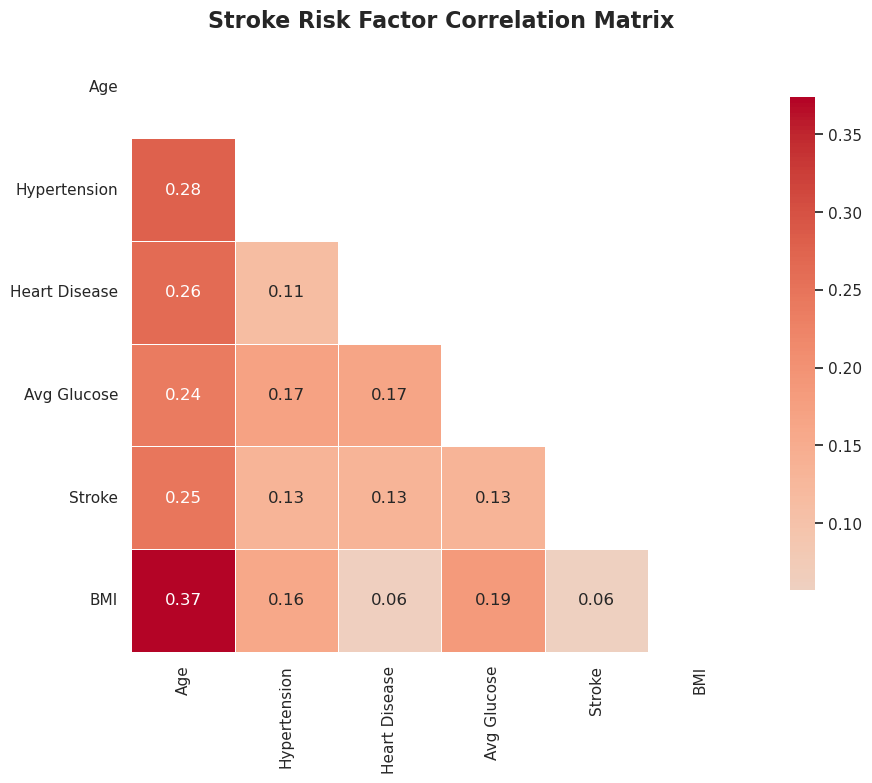

In [23]:
# Вибираємо тільки числові стовпці
numeric_df = df.select_dtypes(include=[np.number])

# Видаляємо стовпчик 'id', бо кореляція з порядковим номером не має сенсу
if 'id' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['id'])

# Перейменовуємо стовпці, щоб вони гарно виглядали на графіку
numeric_df = numeric_df.rename(columns={
    'age': 'Age',
    'hypertension': 'Hypertension',
    'heart_disease': 'Heart Disease',
    'avg_glucose_level': 'Avg Glucose',
    'bmi_filled': 'BMI',
    'stroke': 'Stroke'
})

# Налаштовуємо розмір та білий стиль
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Маска для приховання верхнього трикутника
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))

# Малюємо теплову карту
heatmap = sns.heatmap(numeric_df.corr(), #розраховуємо коефіціент кореляції за Пірсоном
                      mask=mask, 
                      annot=True, 
                      fmt='.2f', 
                      cmap='coolwarm', 
                      center=0, 
                      linewidths=.5, 
                      cbar_kws={"shrink": .8})

# Заголовок
plt.title('Stroke Risk Factor Correlation Matrix', fontsize=16, fontweight='bold')


# Показуємо результат 
plt.show()

### 2. Аналіз медичних факторів ризику
У цьому розділі візуалізуємо, як наявність супутніх захворювань (гіпертонія, серцево-судинні захворювання) та рівень глюкози в крові впливають на частоту виникнення інсульту.


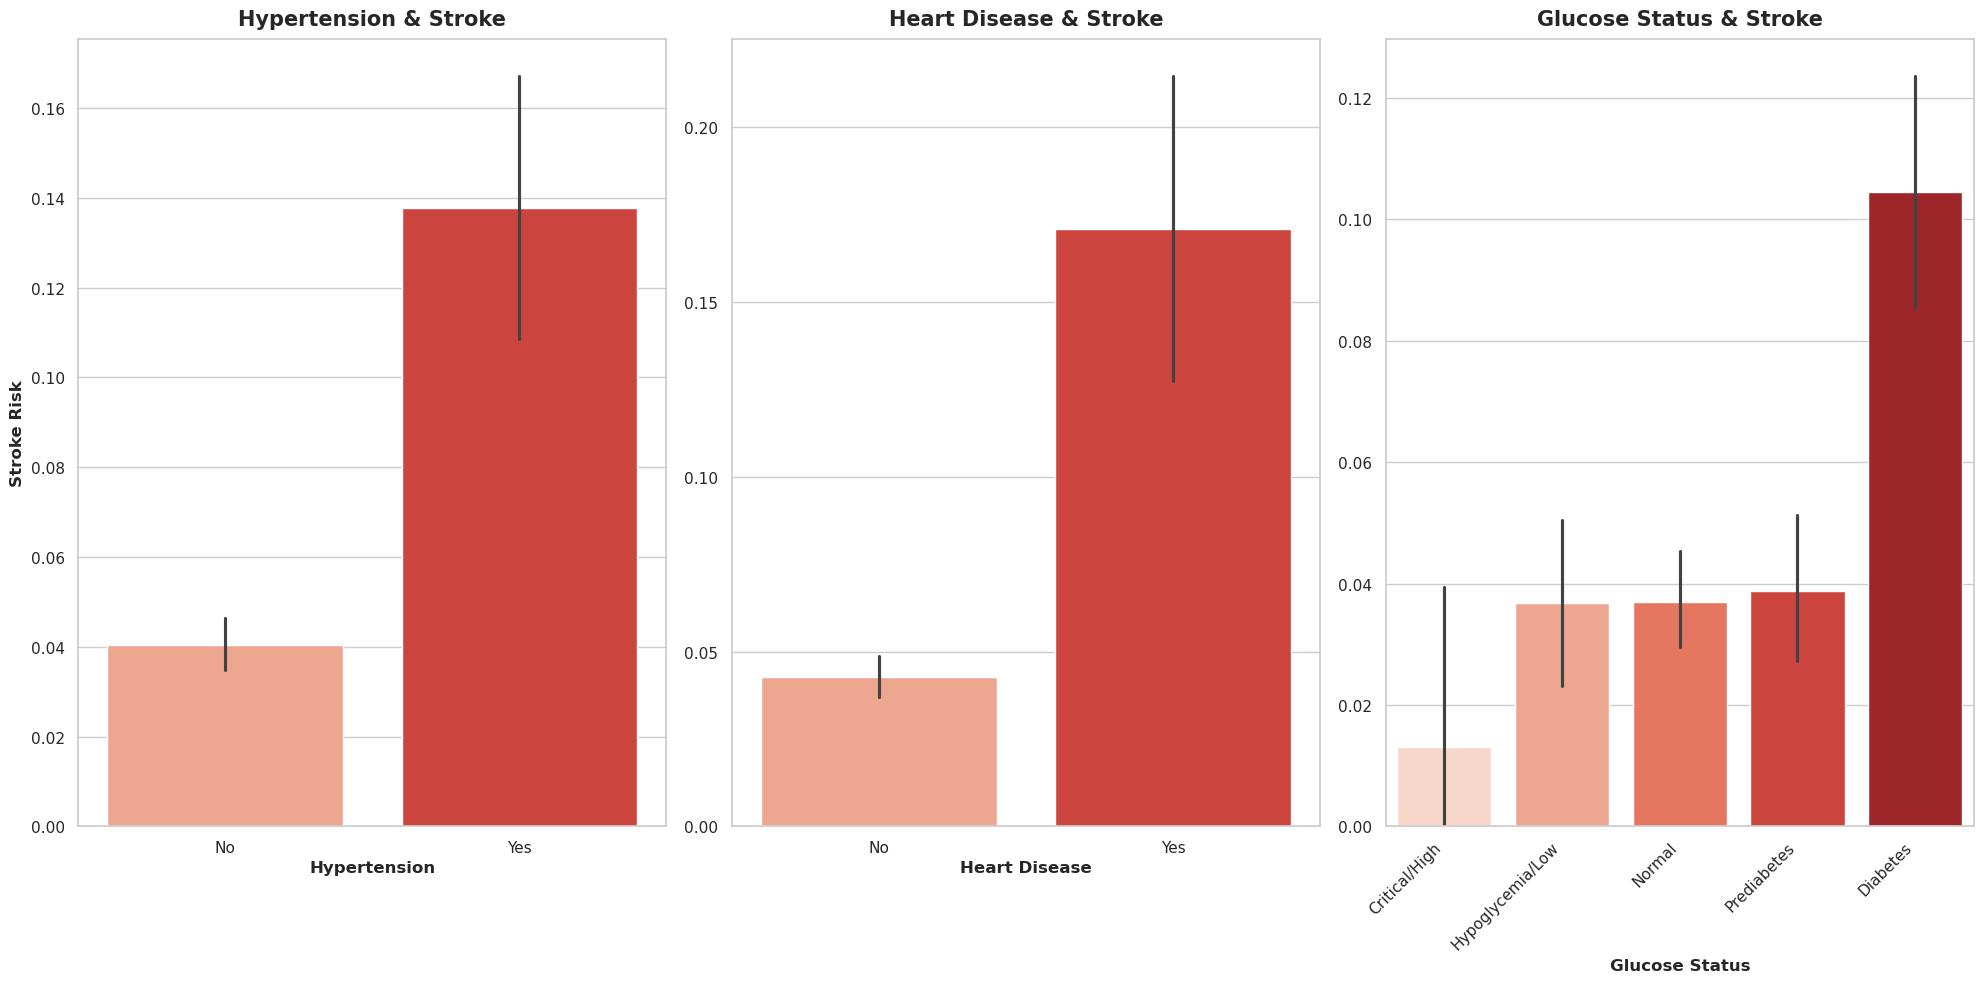

In [24]:
# Налаштування стилю
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# Змінюємо палітру на "Reds"
main_palette = "Reds"

# --- 1. Hypertension ---
# Групуємо та сортуємо, щоб визначити порядок 
hyp_order = df.groupby('hypertension')['stroke'].mean().sort_values().index

sns.barplot(
    ax=axes[0], data=df, x='hypertension', y='stroke', 
    order=hyp_order, hue='hypertension', hue_order=hyp_order,
    palette=main_palette, legend=False
)
axes[0].set_title('Hypertension & Stroke', fontsize=15, fontweight='bold', pad=10)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes']) 
axes[0].set_ylabel('Stroke Risk', fontsize=12, fontweight = 'bold')
axes[0].set_xlabel('Hypertension',fontsize=12, fontweight = 'bold')

# --- 2. Heart Disease ---
heart_order = df.groupby('heart_disease')['stroke'].mean().sort_values().index

sns.barplot(
    ax=axes[1], data=df, x='heart_disease', y='stroke', 
    order=heart_order, hue='heart_disease', hue_order=heart_order,
    palette=main_palette, legend=False
)
axes[1].set_title('Heart Disease & Stroke', fontsize=15, fontweight='bold', pad=10)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_ylabel('')  # Прибираємо дублюючий підпис осі Y
axes[1].set_xlabel('Heart Disease', fontweight = 'bold')

# --- 3. Glucose Status ---
glucose_order = df.groupby('glucose_status')['stroke'].mean().sort_values().index

sns.barplot(
    ax=axes[2], data=df, x='glucose_status', y='stroke', 
    order=glucose_order, hue='glucose_status', hue_order=glucose_order,  
    palette=main_palette, legend=False
)
axes[2].set_title('Glucose Status & Stroke', fontsize=15, fontweight='bold', pad=10)
axes[2].set_xticks(range(len(glucose_order))) 
axes[2].set_xticklabels(glucose_order, rotation=45, ha='right')
axes[2].set_ylabel('')
axes[2].set_xlabel('Glucose Status', fontweight = 'bold')

# Автоматичне вирівнювання елементів
plt.tight_layout()
plt.show()

### 🩺 Аналіз медичних факторів ризику
#### Артеріальна гіпертензія та патології серця
**Результат:**
Перші два графіки показують різке збільшення ймовірності інсульту. У пацієнтів із гіпертензією або хворобами серця ризик виникнення інсульту зростає в 3–4 рази порівняно з групою без цих патологій.

**Клінічний висновок:**
Це підтверджує класичну медичну теорію про те, що пошкодження судинної стінки внаслідок високого артеріального тиску та порушення серцевого ритму є провідними механізмами в розвитку інсульту.

#### Метаболічний профіль (Глюкоза)
**Результат:** 
На графіках видно, що: діабет є найсильнішим фактором ризику в цій категорії.

Найнижчий ризик: Категорії Критично високого та Критично низького/Гіпоглікемії рівнів мають найменшу висоту на графіку. У контексті обробки даних це пояснюється двома факторами:

Низька щільність даних : Пацієнтів із гострою гіпоглікемією у вибірці критично мало,та з гострою гіперглікемією тому суха статистика не показує на них високої частоти інсультів.

Клінічний фактор: Гострі стани вимагають негайної госпіталізації, і пацієнти просто не встигають отримати хронічні пошкодження судин, які є типовими для діабету.
#### Висновок:
діабет + гіпертензія + хвороби серця створюють кумулятивний ефект, суттєво підвищуючи шанси на виникнення інсульту.

### 3. Вплив способу життя та соціальних факторів
Аналіз того, як соціальний статус (тип зайнятості, перебування у шлюбі), а також повсякденні звички (паління) корелюють із ймовірністю виникнення інсульту.

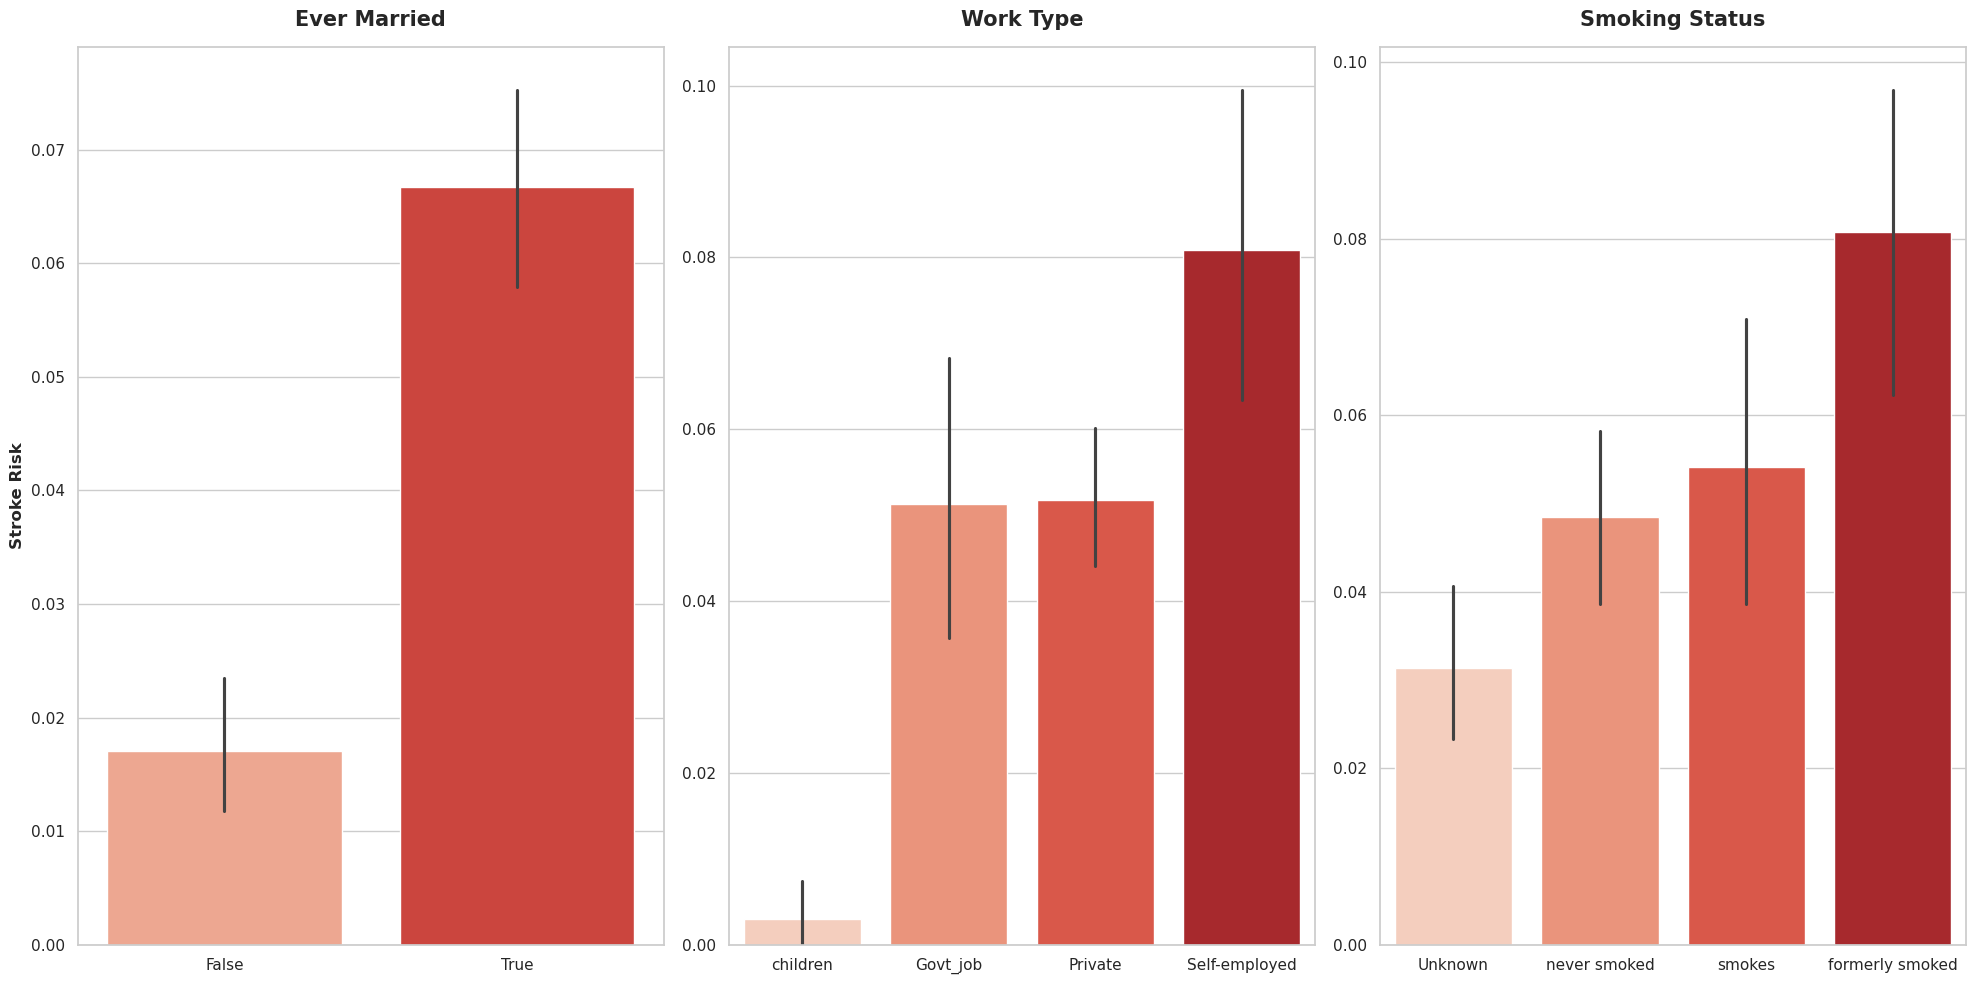

In [68]:
# Налаштування стилю
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 10))


# Список колонок для аналізу та їхні заголовки
lifestyle_cols = ['ever_married', 'work_type', 'smoking_status']
titles = ['Ever Married', 'Work Type', 'Smoking Status']

# Запускаємо цикл по трьох колонках
for i, col in enumerate(lifestyle_cols):
    # Рахуємо середній ризик інсульту для кожної категорії та сортуємо за зростанням
    order = df.groupby(col)['stroke'].mean().sort_values().index
    
  
    sns.barplot(
        ax=axes[i], 
        data=df, 
        x=col, 
        y='stroke', 
        order=order,           # Сортування стовпців на осі X
        hue=col,               # Фарбуємо кожен стовпчик окремо
        hue_order=order,       # Порядок фарбування (від світлого до темного)
        palette='Reds',        
        legend=False           
    )
    
    # Налаштовуємо оформлення для поточного підграфіка
    axes[i].set_title(titles[i], fontsize=15, fontweight='bold', pad=15)
    axes[i].set_xlabel('')
    # Підпис осі Y залишаємо тільки для першого графіка, щоб не захаращувати простір
    axes[i].set_ylabel('Stroke Risk' if i == 0 else '', fontweight='bold')
    
    # Робимо підписи стовпців 
    axes[i].set_xticks(range(len(order)))
    axes[i].set_xticklabels(order, ha='center')

# Автоматичне вирівнювання відступів
plt.tight_layout()
plt.show()

### Висновки
**Сімейний стан (Ever Married):** 

Статистика показує, що люди, які перебувають або перебували у шлюбі ("Yes"), мають вищий показник ризику інсульту. Зазвичай це тісно пов'язано з віковим фактором, адже у шлюбі частіше перебувають люди старшого покоління


**Тип зайнятості (Work Type):** 

Найвищий рівень ризику спостерігається серед самозайнятих людей (Self-employed), що може бути наслідком підвищеного рівня стресу та ненормованого робочого графіка. Натомість категорія дітей (children) очікувано має нульовий або мінімальний ризик через вік.


**Статус паління (Smoking Status):** 

На графіку видно чітку залежність,люди які палили в минулому (formerly smoked) або палять зараз (smokes) мають значно вищий ризик інсульту,порівняно з тими,хто ніколи не палив. 

### 4. Віковий розподіл та критичні точки ризику
Вік вважається одним із найважливіших факторів ризику судинних катастроф. За допомогою графіка щільності розподілу (KDE) ми можемо чітко побачити, як змінюється концентрація випадків інсульту залежно від прожитих років пацієнта.

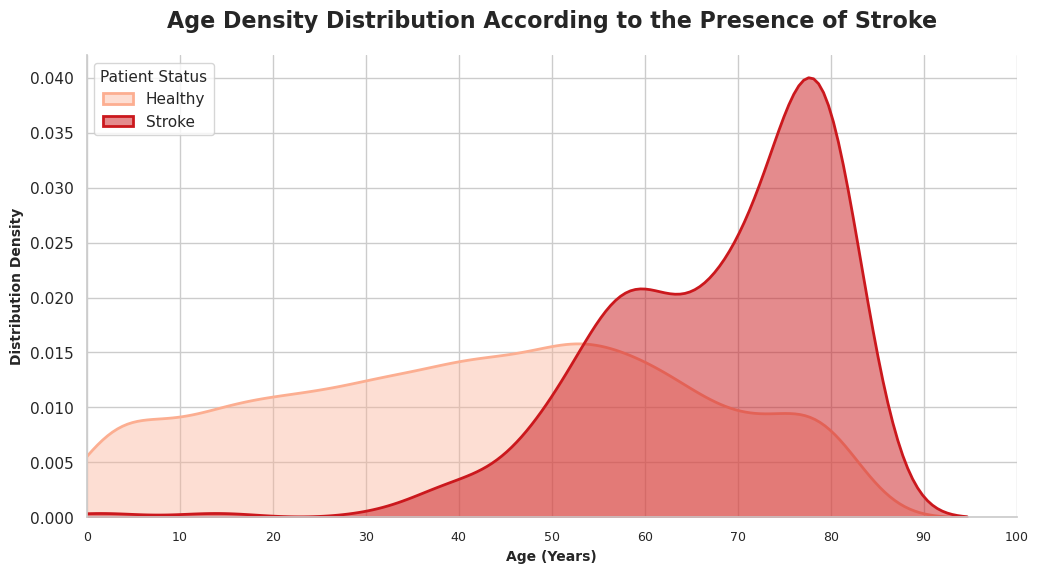

In [45]:
# Налаштування загального стилю
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(12, 6))

# Побудова графіків щільності (KDE)
# Для здорових беремо м'який сіро-рожевий/світлий колір
sns.kdeplot(data=df[df['stroke'] == 0], x='age', fill=True, 
            label='Healthy', color='#fcae91', alpha=0.4, linewidth=2)

# Для інсульту беремо насичений глибокий червоний колір 
sns.kdeplot(data=df[df['stroke'] == 1], x='age', fill=True, 
            label='Stroke', color='#cb181d', alpha=0.5, linewidth=2)

# Оформлення та дизайн 
plt.title('Age Density Distribution According to the Presence of Stroke', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age (Years)', fontsize=10, fontweight='bold')
plt.ylabel('Distribution Density', fontsize=10,  fontweight='bold')
plt.xticks(range(0,110,10), fontsize=9)

# Налаштування легенди
plt.legend(title='Patient Status', title_fontsize='11', loc='upper left', frameon=True)

plt.xlim(0, 100)

# Прибираємо верхню та праву рамки для візуальної легкості
sns.despine()

plt.show()

### Висновки:
**Зміщення кривої інсульту:** 

- Крива розподілу здорових людей  має плавний характер із вершиною в районі 50–55 років.
  
- Ккрива пацієнтів, які перенесли інсульт, критично зміщена праворуч, у бік старшого покоління. Основна концентрація хворих припадає на віковий діапазон від 65 до 85 років.


**Критична межа (50-55 років):**


До 50-55 років лінії графіків мають кардинально різну висоту: ймовірність зустріти пацієнта з інсультом у молодому віці є вкрай низькою.
Одразу після проходження відмітки 50-55 років щільність здорових людей починає стрімко падати, а щільність випадків інсульту — експоненційно зростати. Це робить вік 50-55+ головним маркером для старту активної медичної профілактики.


**Дитячий та підлітковий вік:**


До 25років червона крива знаходиться майже на нульовому рівні. Це підтверджує, що для даної вибірки інсульт у дітей доволі таки рідким явищем.

### 5. Гендерна структура пацієнтів
Необхідно з'ясувати, чи існує гендерна схильність до інсульту у межах нашої вибірки. 

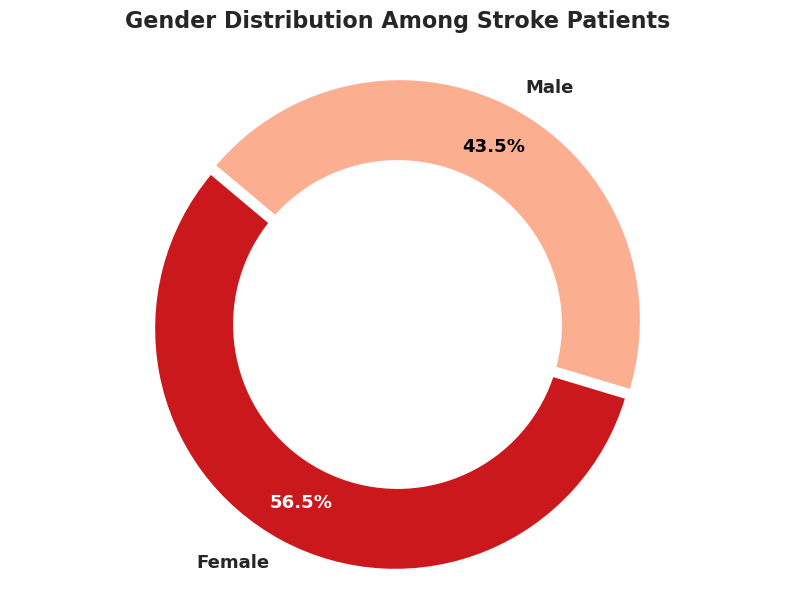

In [50]:
# Беремо тільки пацієнтів з інсультом
stroke_patients = df[df['stroke'] == 1]

# Рахуємо кількість за гендером
gender_counts = stroke_patients['gender'].value_counts()

# Налаштування розміру на кольорів
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#cb181d', '#fcae91'] 

# Будуємо кругову діаграму
wedges, texts, autotexts = ax.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.82,                              
    explode=[0.02] * len(gender_counts),          # розріз між шматками
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)

# Задаємо колір тексту відсотків 
autotexts[0].set_color('white')
autotexts[1].set_color('black')

# Малюємо біле коло по центру
centre_circle = plt.Circle((0,0), 0.68, fc='white')
ax.add_artist(centre_circle)

# Оформлення
plt.title('Gender Distribution Among Stroke Patients', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')  # Гарантує, що діаграма буде ідеально круглою, а не овальною

plt.show()

**Висновки:**

- Серед усіх зафіксованих випадків інсульту у вибірці, більшу частину становлять жінки — 58.3%.
- Частка чоловіків є меншою і складає 41.7%.
  
**Клінічна інтерпретація результату:**

У медичній статистиці загальна чисельність інсультів серед жінок часто виявляється вищою з двох основних причин. По-перше, середня тривалість життя жінок у більшості країн світу є більшою, а вік, як ми довели на попередньому кроці, є критичним фактором ризику. Простіше кажучи, у вибірці банально більше жінок старшого віку.
По-друге, жінки мають додаткові специфічні чинники ризику у старшому віці (наприклад, гормональні перебудови в період менопаузи, що негативно впливають на еластичність судин).

### 6. Вплив індексу маси тіла (ІМТ / BMI)
Індекс маси тіла є одним із ключових модифікованих факторів ризику . Для відстеження динаміки я розподілили пацієнтів за міжнародними медичними стандартами на 4 категорії: недостатня вага (Underweight), нормальна вага (Normal), надлишкова вага (Overweight) та ожиріння (Obese).

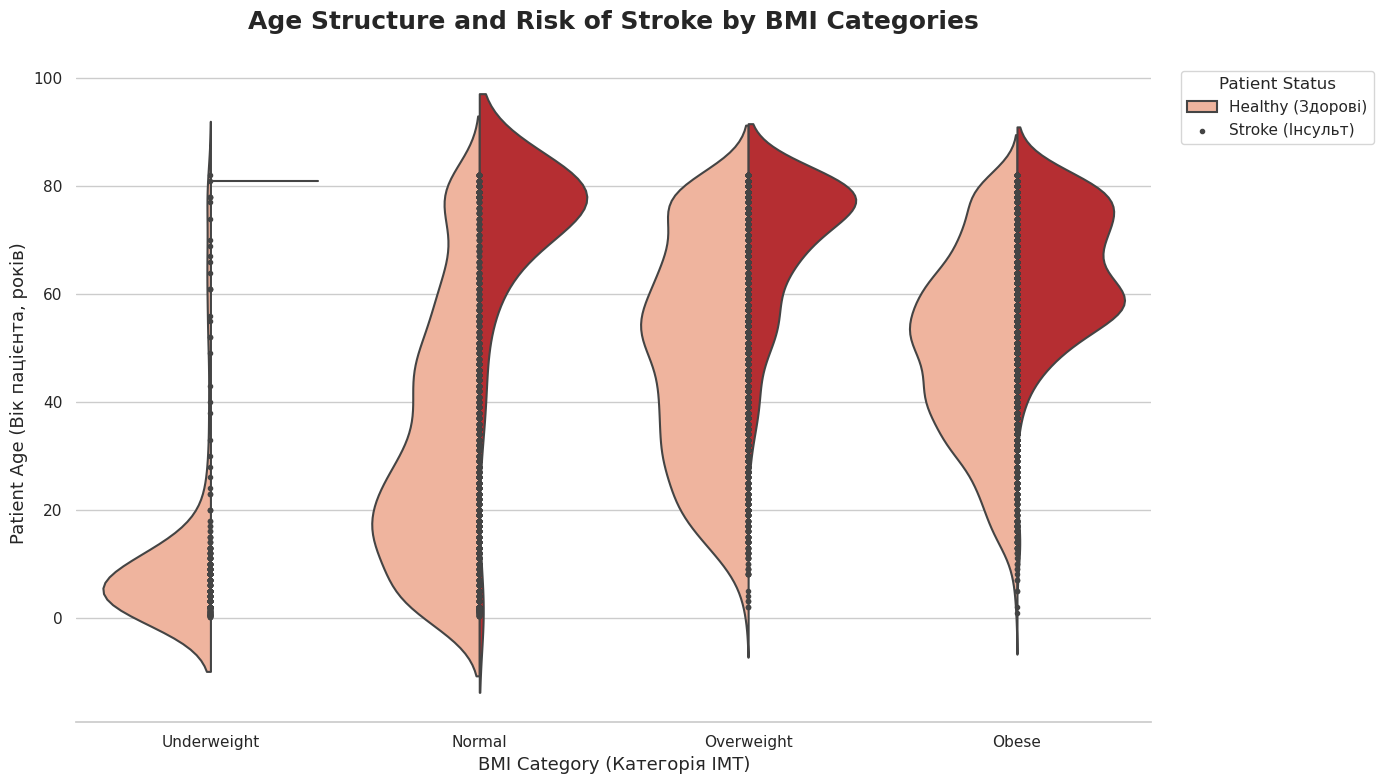

In [51]:
# Налаштування стилю 
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
project_palette = {0: "#fcae91", 1: "#cb181d"}

# Побудова скрипкового графіка
sns.violinplot(
    data=df, 
    x='bmi_category', 
    y='age', 
    hue='stroke', 
    split=True,                  # Ділить скрипку навпіл: зліва здорові, справа інсульт
    inner='point',               # Показує точки реальних пацієнтів всередині розподілу
    density_norm='width',        # Вирівнює ширину всіх скрипок для зручного порівняння форме
    palette=project_palette, 
    order=['Underweight', 'Normal', 'Overweight', 'Obese'], # порядок
    linewidth=1.5 
)

# Написи
plt.title('Age Structure and Risk of Stroke by BMI Categories', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('BMI Category (Категорія ІМТ)', fontsize=13)
plt.ylabel('Patient Age (Вік пацієнта, років)', fontsize=13)

# Налаштування легенди
plt.legend(
    title='Patient Status', 
    bbox_to_anchor=(1.02, 1),    # Зсуваємо легенду трохи вбік, щоб вона не перекривала графік
    loc='upper left', 
    labels=['Healthy (Здорові)', 'Stroke (Інсульт)']
)

# Рамка
sns.despine(left=True)

plt.tight_layout()
plt.show()

#### Bисновки 

Візуалізація чітко демонструє, що надлишкова вага та ожиріння підвищують ризик інсульту раніше, ніж у людей з нормальною вагою
  
- Поглянувши на «скрипку» нормальної ваги (Normal), видно, що червона половинка (випадки інсульту) починає концентруватися переважно після 60-65 років.
  
- Однак у категоріях надлишкової ваги та ожиріння (Overweight та Obese) «вікно ризику» починає відкриватися значно раніше. Червона зона помітно опускається донизу, фіксуючи випадки інсульту вже у пацієнтів віком 40–50 років.

**Категорія недостатньої ваги (Underweight):**

У цій групі зафіксовано найменшу кількість пацієнтів загалом (скрипка дуже тонка). Випадки інсульту тут поодинокі та локалізовані виключно у глибокому старечому віці (75+ років), що може бути викликано загальним виснаженням організму (кахексією) або супутніми віковими патологіями.


**Загальний висновок:**

Високий ІМТ зміщує статистичну ймовірність отримання інсульту на 15–20 років раніше, порівняно з групою людей, які підтримують нормальну масу тіла. Це робить контроль ваги одним із найефективніших інструментів ранньої профілактики.

### 7. Синергія: Поєднання цукру та високого тиску
Ця теплова карта показує, як сильно змінюється ризик виникнення інсульту залежно від рівня цукру в крові (глюкози) та наявності підвищеного артеріального тиску (гіпертензії).

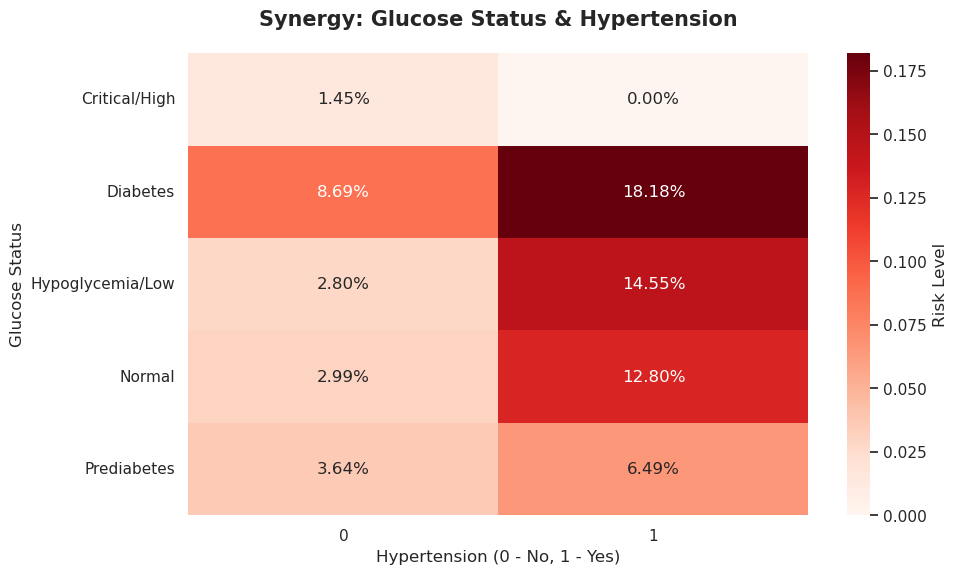

In [56]:
# Cтворюємо зведену таблицю
pivot_glucose_hyp = df.pivot_table(index='glucose_status', 
                                   columns='hypertension', 
                                   values='stroke', 
                                   aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_glucose_hyp, annot=True, fmt=".2%", cmap="Reds", cbar_kws={'label': 'Risk Level'})

plt.title('Synergy: Glucose Status & Hypertension', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Hypertension (0 - No, 1 - Yes)', fontsize=12)
plt.ylabel('Glucose Status', fontsize=12)

plt.show()

#### Bисновки :
**Найвища небезпека :** 

Найвищий ризик інсульту спостерігається у людей, які мають одночасно і діабет (Diabetes), і високий тиск (Hypertension). Коли ці два фактори об'єднуються, вони підсилюють один одного, створюючи критичну загрозу для судин.

Навіть якщо рівень цукру в крові пацієнта повністю в нормі , наявність високого тиску самостійно подвоює ризик інсульту. Тиск є дуже потужним руйнівником судинних стінок.
 

#### 8. Синергія: Поєднання хвороб серця та гіпертензії
Тут я проаналізую суто кардіологічний профіль ризику.

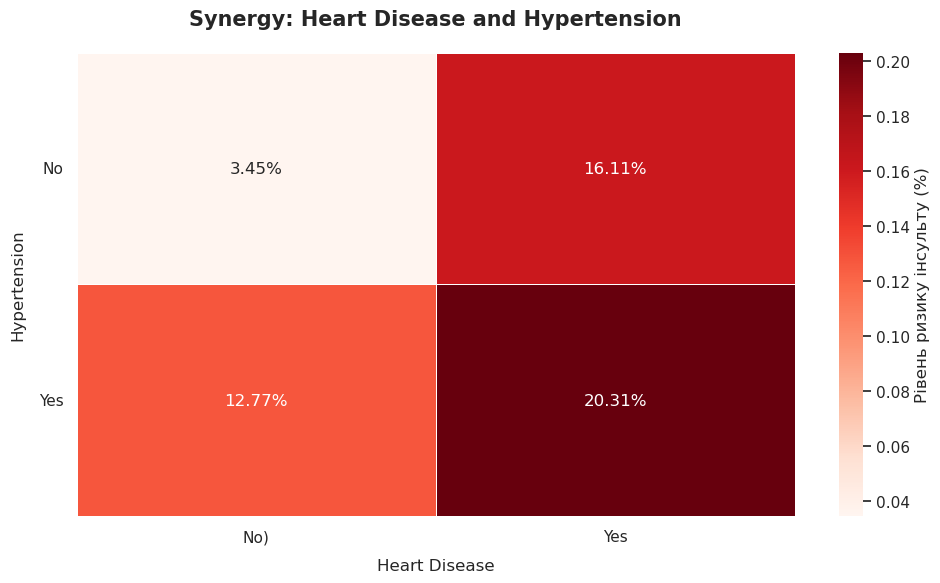

In [60]:
#  Створюємо зведену таблицю 
pivot_heart_hyp = df.pivot_table(
    index='hypertension', 
    columns='heart_disease', 
    values='stroke', 
    aggfunc='mean'
)

# Налаштування розміру
plt.figure(figsize=(10, 6))

# Будуємо теплову карту (Heatmap) з червоною палістрою 'Reds'
sns.heatmap(
    pivot_heart_hyp, 
    annot=True, 
    fmt=".2%",                  # Виводимо значення у вигляді чітких відсотків (наприклад, 2.30%)
    cmap="Reds",                # Твоя фірмова палітра проекту
    linewidths=.5,              # Тонкі білі лінії між секторами
    cbar_kws={'label': 'Рівень ризику інсульту (%)'} # Підпис шкали кольорів укр
)

# Оформлення, дизайн 
plt.title('Synergy: Heart Disease and Hypertension', fontsize=15, fontweight='bold', pad=20)
plt.xticks([0.5, 1.5], ['No)', 'Yes'])
plt.yticks([0.5, 1.5], ['No', 'Yes'], rotation=0)

plt.xlabel('Heart Disease', fontsize=12, labelpad=10)
plt.ylabel('Hypertension', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

**Висновок:** 

- Помітно дуже сильне зростання ризику, коли обидва діагнози присутні у пацієнта одночасно.
  
**Клінічний висновок:**

Хвороби серця часто супроводжуються порушеннями ритму (наприклад, фібриляцією передсердь), а гіпертензія створює постійний надмірний тиск на стінки артерій. Синергія цих факторів призводить до того, що в даній групі пацієнтів ризик виникнення інсульту в кілька разів перевищує середній показник по всій вибірці.

#### 7. Аналіз глюкози: пошук критичних меж
Я досліджую взаємозв'язок між віком пацієнта та середнім рівнем глюкози в крові. Мета — визначити, чи існує точка коли поєднання високого рівня цукру та віку робить ризик виникнення інсульту майже неминучим.

(Рівень глюкози вище 140–150 мг/дЛ часто класифікують як предіабет або діабет.Я додамо цю розмежувальну лінію на графік для більшої наочності. )

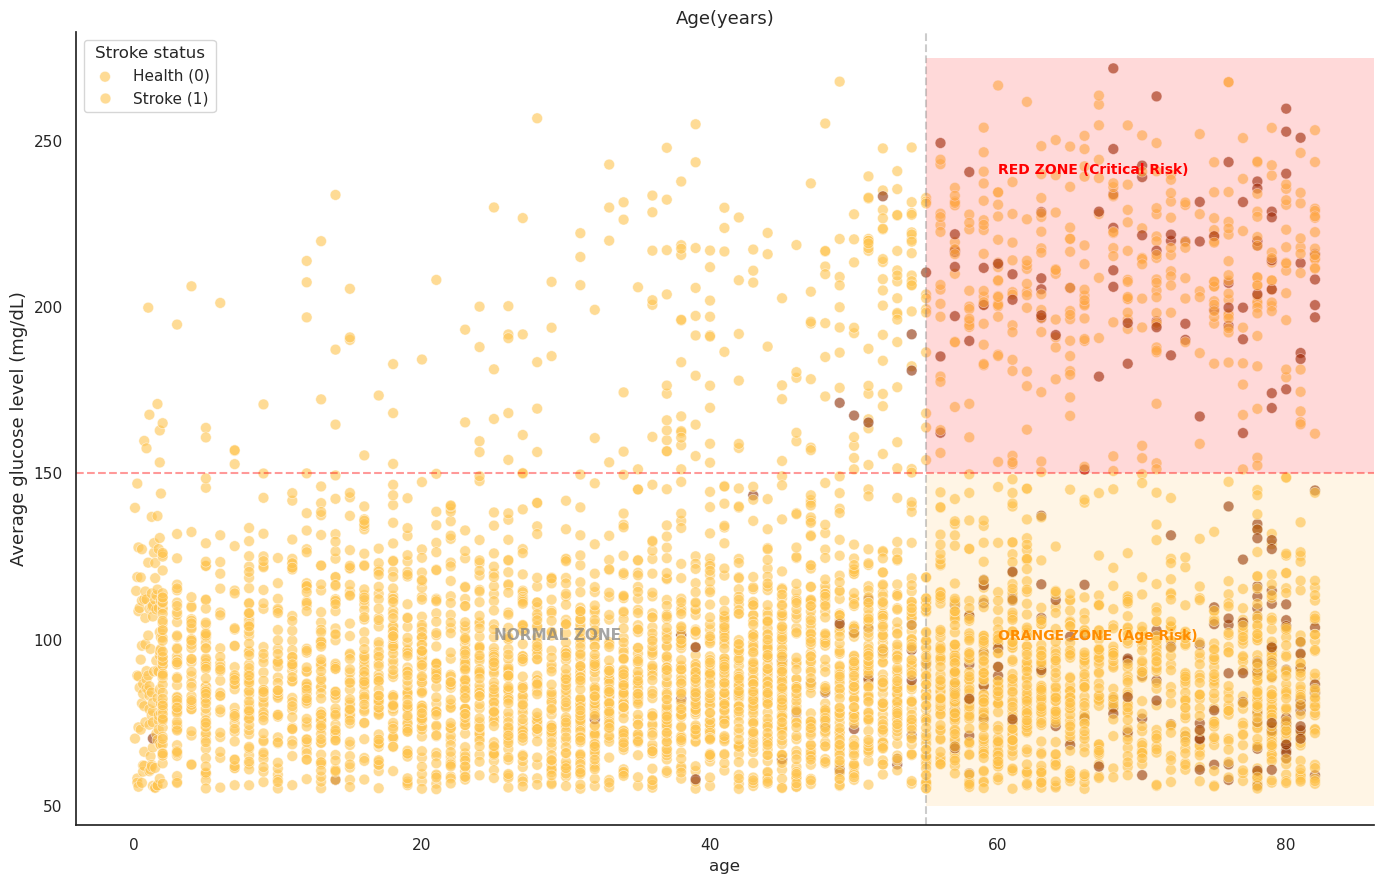

In [66]:
import matplotlib.patches as patches
# Налаштування стилю
plt.figure(figsize=(14, 9))
sns.set_theme(style="white")

# Створення Scatter Plot
sns.scatterplot(
    data=df, 
    x='age', 
    y='avg_glucose_level', 
    hue='stroke', 
    palette={0: "#fec44f", 1: "#8c2d04"}, 
    alpha=0.6, 
    s=60, 
    edgecolor='white',
    linewidth=0.5
)

# Додавання зони
ax = plt.gca()

# Помаранчева зона : Age > 55, lvl_glucose < 150
orange_zone = patches.Rectangle((55, 50), 35, 100, linewidth=0, edgecolor='none', facecolor='orange', alpha=0.1)
ax.add_patch(orange_zone)

# Червона зона: Age > 55, lvl_glucose > 150
red_zone = patches.Rectangle((55, 150), 35, 125, linewidth=0, edgecolor='none', facecolor='red', alpha=0.15)
ax.add_patch(red_zone)

# лінія
plt.axhline(y=150, color='red', linestyle='--', alpha=0.4)
plt.axvline(x=55, color='grey', linestyle='--', alpha=0.4)

# Написи
plt.text(25, 100, 'NORMAL ZONE', fontsize=11, fontweight='bold', color='grey', alpha=0.7)
plt.text(60, 100, 'ORANGE ZONE (Age Risk)', fontsize=10, fontweight='bold', color='darkorange')
plt.text(60, 240, 'RED ZONE (Critical Risk)', fontsize=10, fontweight='bold', color='red')

# Заголовки
plt.title('Age(years)', fontsize=13)
plt.ylabel('Average glucose level (mg/dL)', fontsize=13)
plt.legend(title='Stroke status', loc='upper left', labels=['Health (0)', 'Stroke (1)'])

sns.despine()
plt.tight_layout()
plt.show()

In [67]:
# 1. Червона зона: Age > 55 and Sugar > 150 (Високий ризик)
red_zone = df[(df['age'] > 55) & (df['avg_glucose_level'] > 150)]
red_zone_risk = (red_zone['stroke'].mean() * 100).round(2)

# 2. Помаранчева зона: Age > 55 and Sugar <= 150 (Ризик за віком)
orange_zone = df[(df['age'] > 55) & (df['avg_glucose_level'] <= 150)]
orange_zone_risk = (orange_zone['stroke'].mean() * 100).round(2)

# 3. Нормальна зона: Age <= 55 and Sugar <= 150 (Звичайнй рівень)
normal_zone = df[(df['age'] <= 55) & (df['avg_glucose_level'] <= 150)]
normal_zone_risk = (normal_zone['stroke'].mean() * 100).round(2)

# Розрахунок коефіцієнтів (із захистом від ділення на нуль)
multiplier_orange = (orange_zone_risk / normal_zone_risk).round(1) if normal_zone_risk > 0 else 0
multiplier_red = (red_zone_risk / normal_zone_risk).round(1) if normal_zone_risk > 0 else 0

print(f"📊 СТАТИСТИКА ЗОН РИЗИКУ:")
print(f"------------------------------------")
print(f"🟢 Нормальна зона: {normal_zone_risk}%")
print(f"🟠 Помаранчева зона (Вік 55+ та цукор <= 150): {orange_zone_risk}% (Ризик у {multiplier_orange} разів вищий)")
print(f"🔴 Червона зона (Вік 55+ та цукор > 150): {red_zone_risk}% (Ризик у {multiplier_red} разів вищий!)")

📊 СТАТИСТИКА ЗОН РИЗИКУ:
------------------------------------
🟢 Нормальна зона: 1.02%
🟠 Помаранчева зона (Вік 55+ та цукор <= 150): 10.33% (Ризик у 10.1 разів вищий)
🔴 Червона зона (Вік 55+ та цукор > 150): 18.72% (Ризик у 18.4 разів вищий!)


**Висновок:**
Фінальна візуалізація чітко підкреслює закономірність: пацієнти старшого віку з високим рівнем глюкози демонструють найвищу частоту виникнення інсульту. Хоча вік сам по собі підвищує небезпеку, ймовірність інсульту зростає в рази, коли він поєднується з метаболічними та серцево-судинними патологіями, такими як гіпертензія або підвищений рівень глюкози.

## **Фінальні висновки**
Розвідувальний аналіз (EDA) дозволив виявити кілька ключових факторів, пов'язаних із підвищеним ризиком виникнення інсульту.
Результати дослідження показують, що вік є найбільш впливовим чинником — випадки інсульту трапляються значно частіше серед старшого покоління. Такі медичні діагнози, як гіпертензія та хвороби серця, також демонструють дуже сильний зв'язок із появою цієї патології.

Крім того, помітний взаємозв'язок із частотою інсультів мають метаболічні показники — зокрема, підвищений рівень глюкози та індекс маси тіла (ІМТ).

Статистика показує, що люди, які перебувають або перебували у шлюбі , мають вищий показник ризику інсульту. Зазвичай це тісно пов'язано з віковим фактором, адже у шлюбі частіше перебувають люди старшого покоління

Аналіз чітко вказує на те, що ризик інсульту суттєво зростає, **коли у пацієнта є кілька факторів ризику одночасно**. Загалом, випадки інсульту концентруються серед людей із комбінацією серцево-судинних та метаболічних проблем. Це підкреслює важливість комплексного оцінювання кількох змінних разом під час прогнозування ризиків для пацієнта.

Хоча у даному датасеті жінки представлені серед хворих трохи більше, наявних даних недостатньо, щоб точно визначити першопричину такої закономірності.

**Рекомендації**
На основі  даних можна запропонувати кілька практичних рекомендацій:

1. **Фокусувати профілактичні скринінги на старшому поколінні**
   Люди віком від 50 років становлять групу з найвищою фіксованою частотою інсультів, тому їх потрібно пріоритезувати у програмах профілактичної медицини.
2. **Ретельно контролювати серцево-судинні захворювання**
   Регулярне обстеження та контроль артеріального тиску (гіпертензії) й патологій серця можуть допомогти суттєво знизити ризик розвитку інсульту.
3. **Відстежувати показники метаболічного здоров'я**
   Моніторинг рівня глюкози в крові та індексу маси тіла (ІМТ) дозволить вчасно виявляти пацієнтів у зоні підвищеного ризику та забезпечувати раннє медичне втручання.
4. **Виявляти групи високого ризику за сукупністю кількох індикаторів**
   Системам охорони здоров'я доцільно об'єднувати демографічні, медичні та метаболічні змінні для комплексного виявлення пацієнтів із критичною загрозою інсульту.

---

## **Практична цінність аналізу**

Результати, отримані в ході цього дослідження, мають високу практичну цінність для кількох галузей, які працюють із медичними даними.

### 1. Медичні установи та заклади охорони здоров'я
Лікарні та клініки можуть використовувати подібний аналіз для більш раннього виявлення пацієнтів із групи високого ризику. Розуміння того, які саме фактори найсильніше пов'язані з інсультом, допомагає медичним працівникам:
- ефективно розподіляти пріоритети для профілактичних скринінгів;
- пильніше моніторити стан пацієнтів із кількома супутніми діагнозами;
- розробляти цільові програми профілактики.

Раннє виявлення та превентивні заходи здатні суттєво зменшити кількість важких випадків інсульту та покращити результати лікування.

### 2. Страхові компанії
Постачальники послуг медичного страхування можуть використовувати аналогічні аналітичні підходи для точнішої оцінки профілів ризику клієнтів. Аналізуючи такі фактори, як вік, гіпертензія та метаболічні показники, страховики можуть:
- прогнозувати потенційні витрати на медичне обслуговування;
- розробляти гнучкі страхові модели на основі реальних ризиків;
- заохочувати клієнтів із групи ризику до участі у програмах профілактики здоров'я.

Це допомагає знизити довгострокові витрати страхових компаній завдяки своєчасному попередженню критичних станів.

### 3. Організації охорони здоров'я та державні інституції
Державні медичні агенції можуть спиратися на цей тип аналізу для розробки стратегій профілактики на рівні всього населення. Чітке визначення найбільш вразливих демографічних груп дозволяє ефективніше розподіляти державні ресурси та запускати точкові інформаційні кампанії про здоров'я.